# Sell-Price EDA — Idealista sale listings
**Airbnb Investment Intelligence Platform · sell-side model**

Sanity-checks the scraped Idealista **sale** data (Madrid, Barcelona, Málaga)
before modelling: coverage, distributions, €/m² by district, price–size
relationship, and outliers.

> **Leakage note:** `price_per_m2` (= price ÷ size) is shown here for
> intuition only. It must **never** be a feature in a model whose target is
> `price`.

## 1. Setup & load

In [1]:
%matplotlib inline
import warnings; warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

from airbnb_iip.data.idealista_sale import load_sale_listings, clean_sale_listings

raw   = load_sale_listings()
clean = clean_sale_listings(raw)
print(f"raw   : {len(raw):,} rows × {raw.shape[1]} cols")
print(f"clean : {len(clean):,} rows  (dropped {len(raw)-len(clean):,})")
clean.head(3)

raw   : 14,909 rows × 20 cols
clean : 14,862 rows  (dropped 47)


,property_code,price,size_m2,price_per_m2,rooms,bathrooms,property_type,status,floor_raw,has_lift,exterior,new_development,district,neighborhood,municipality,province,latitude,longitude,city,floor_num
0,111667331,44000,67.0,657,1,1,flat,good,1,True,True,False,Villa de Vallecas,Ensanche de Vallecas - La Gavia,Madrid,Madrid,40.376345,-3.628137,madrid,1.0
1,108361598,50000,37.0,1351,1,2,flat,good,NaN,False,True,False,Puente de Vallecas,Entrevías,Madrid,Madrid,40.383322,-3.671096,madrid,NaN
2,108007282,50000,37.0,1351,1,1,flat,good,bj,False,<NA>,False,Puente de Vallecas,Entrevías,Madrid,Madrid,40.380007,-3.670678,madrid,0.0


## 2. Data coverage & quality

In [2]:
cov = pd.DataFrame({
    "non_null_%": (raw.notna().mean() * 100).round(1),
    "n_unique": raw.nunique(),
})
cov.sort_values("non_null_%", ascending=False)

,non_null_%,n_unique
property_code,100.0,14909
price,100.0,1692
size_m2,100.0,461
price_per_m2,100.0,4371
rooms,100.0,16
bathrooms,100.0,13
property_type,100.0,6
new_development,100.0,2
province,100.0,3
municipality,100.0,3


In [3]:
print("rows per city (clean):")
print(clean["city"].value_counts())
print("\nduplicate property_code in raw load:", raw["property_code"].duplicated().sum())

rows per city (clean):
city
madrid       5030
barcelona    4993
malaga       4839
Name: count, dtype: int64

duplicate property_code in raw load: 0


## 3. Target — sale price (€)

Price is heavily right-skewed, so the model will train on `log1p(price)`.

,count,min,10%,50%,90%,max
city,,,,,,
barcelona,4993.0,28000.0,139000.0,263000.0,359000.0,380000.0
madrid,5030.0,44000.0,172000.0,254900.0,325000.0,345000.0
malaga,4839.0,40300.0,210000.0,385000.0,1030000.0,4975000.0


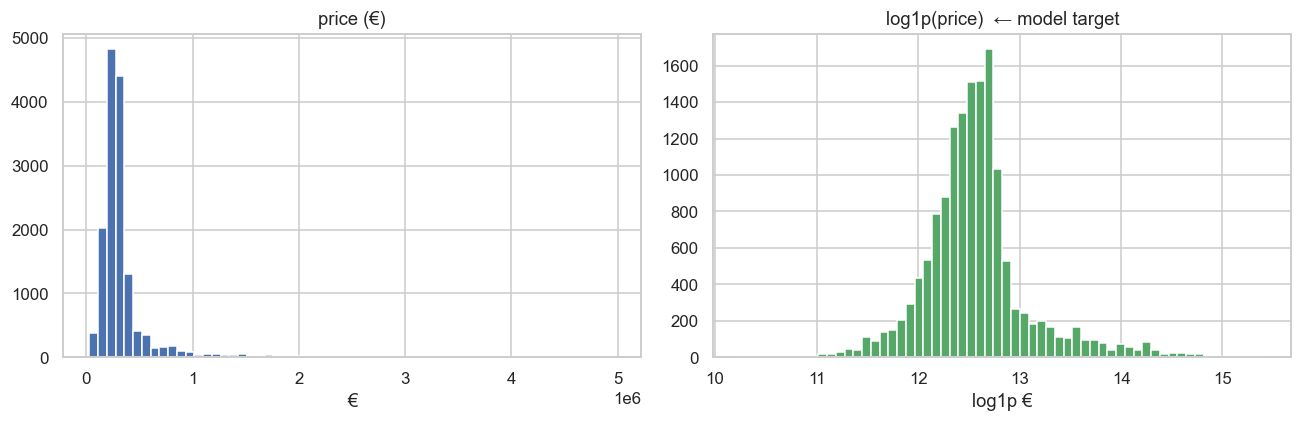

In [4]:
display(clean.groupby("city")["price"].describe(percentiles=[.1,.5,.9])
        [["count","min","10%","50%","90%","max"]].round(0))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(clean["price"], bins=60, color="#4C72B0", edgecolor="white")
ax[0].set_title("price (€)"); ax[0].set_xlabel("€")
ax[1].hist(np.log1p(clean["price"]), bins=60, color="#55A868", edgecolor="white")
ax[1].set_title("log1p(price)  ← model target"); ax[1].set_xlabel("log1p €")
plt.tight_layout()

## 4. Size (m²)

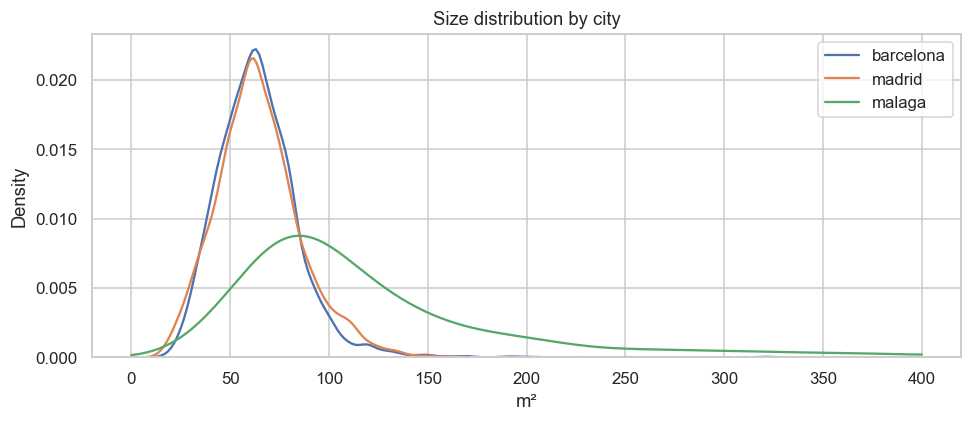

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
for city, g in clean.groupby("city"):
    sns.kdeplot(g["size_m2"], label=city, ax=ax, clip=(0, 400))
ax.set_title("Size distribution by city"); ax.set_xlabel("m²"); ax.legend()
plt.tight_layout()

## 5. Price per m² (the sell-side anchor)

This is the headline number the finance engine's *sell* scenario rests on
(`sale value ≈ €/m² × size`). Shown by city, then by district.

,min,10%,50%,90%,max
city,,,,,
barcelona,401.0,2364.0,4167.0,6058.0,15750.0
madrid,657.0,2619.0,3904.0,6400.0,17188.0
malaga,504.0,2282.0,3880.0,6653.0,19130.0


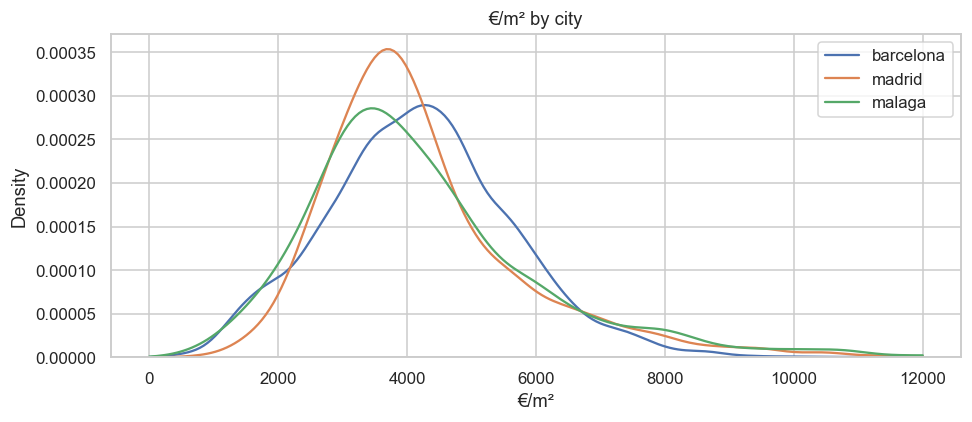

In [6]:
display(clean.groupby("city")["price_per_m2"].describe(percentiles=[.1,.5,.9])
        [["min","10%","50%","90%","max"]].round(0))

fig, ax = plt.subplots(figsize=(9, 4))
for city, g in clean.groupby("city"):
    sns.kdeplot(g["price_per_m2"], label=city, ax=ax, clip=(0, 12000))
ax.set_title("€/m² by city"); ax.set_xlabel("€/m²"); ax.legend()
plt.tight_layout()

### 6. €/m² ranked by district

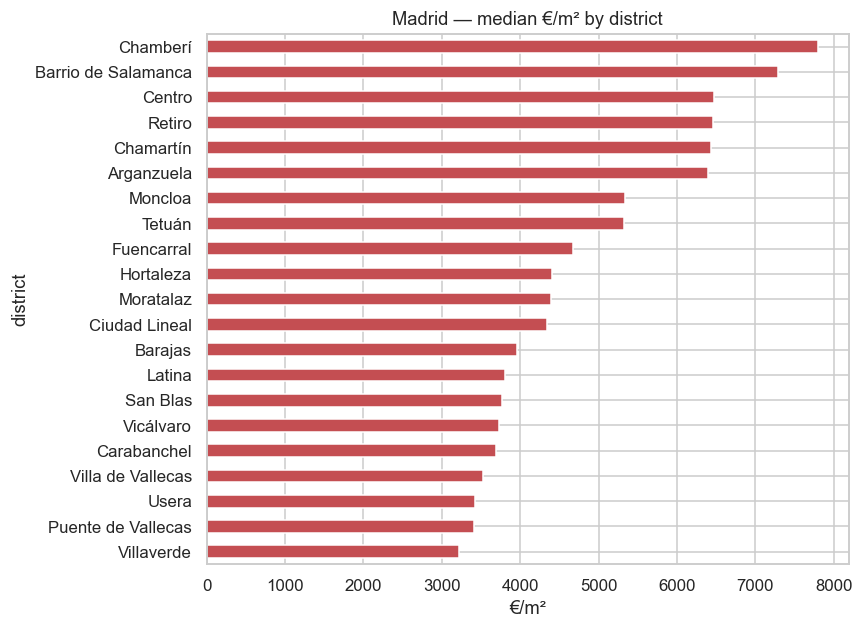

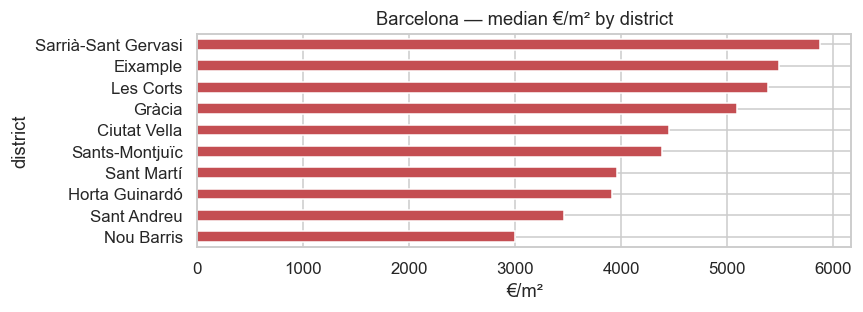

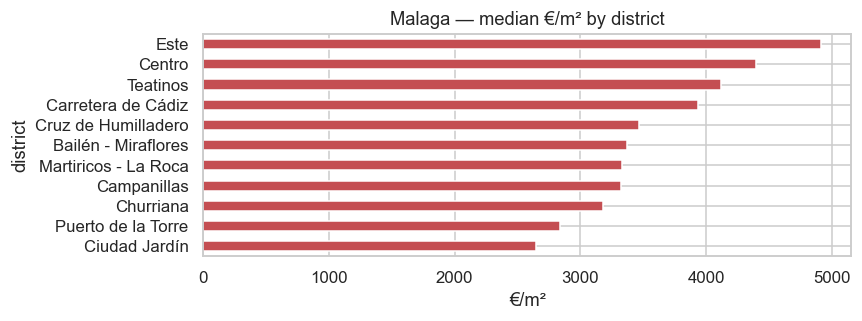

In [7]:
for city in ["madrid", "barcelona", "malaga"]:
    g = clean[clean["city"] == city]
    med = (g.groupby("district")["price_per_m2"].median()
             .sort_values(ascending=False))
    fig, ax = plt.subplots(figsize=(8, max(3, 0.28*len(med))))
    med.plot.barh(ax=ax, color="#C44E52")
    ax.invert_yaxis()
    ax.set_title(f"{city.title()} — median €/m² by district")
    ax.set_xlabel("€/m²")
    plt.tight_layout(); plt.show()

## 7. Price vs size

If price scaled perfectly linearly with size, €/m² would be constant. It
isn't — larger flats have lower €/m² — which is exactly why we model total
price (with size as a feature) rather than €/m² × size.

corr(log size, log price) = 0.706


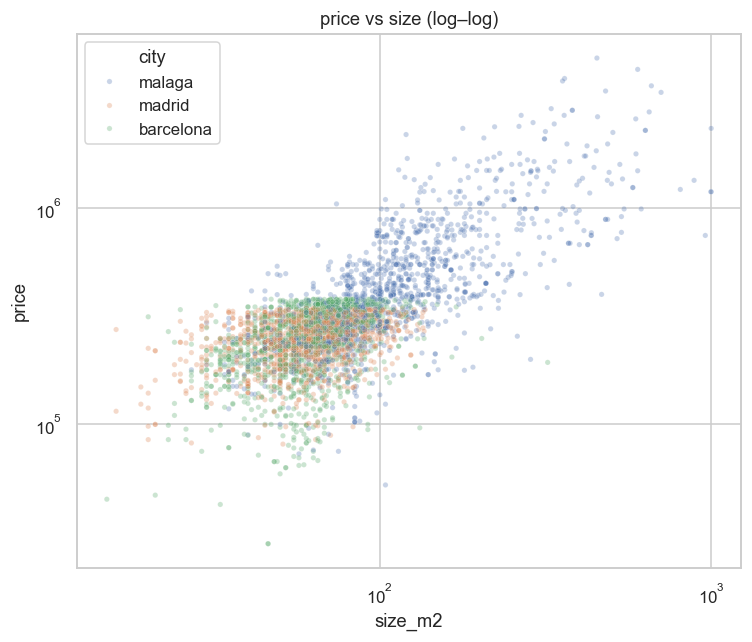

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=clean.sample(min(4000, len(clean)), random_state=0),
                x="size_m2", y="price", hue="city", alpha=0.3, s=12, ax=ax)
ax.set(xscale="log", yscale="log", title="price vs size (log–log)")
plt.tight_layout()

corr = np.corrcoef(np.log1p(clean["size_m2"]), np.log1p(clean["price"]))[0, 1]
print(f"corr(log size, log price) = {corr:.3f}")

## 8. Property type & condition

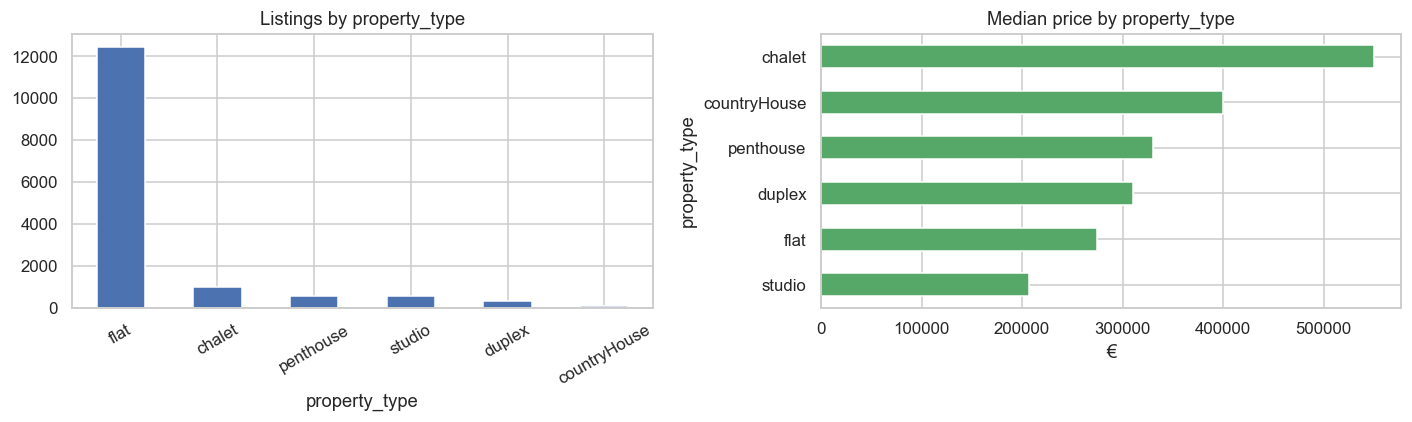

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
clean["property_type"].value_counts().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set_title("Listings by property_type"); ax[0].tick_params(axis="x", rotation=30)

(clean.groupby("property_type")["price"].median().sort_values()
      .plot.barh(ax=ax[1], color="#55A868"))
ax[1].set_title("Median price by property_type"); ax[1].set_xlabel("€")
plt.tight_layout()

,count,median
status,,
good,12210,280000.0
newdevelopment,581,338000.0
renew,1974,255000.0


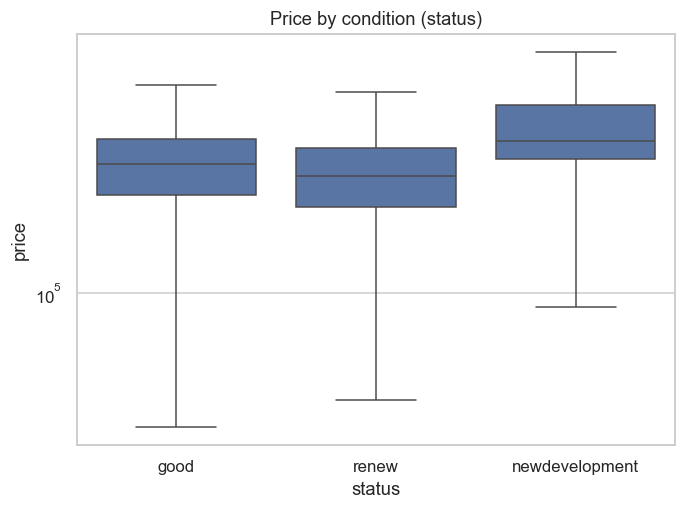

In [10]:
display(clean.groupby("status")["price"].agg(["count", "median"]).round(0))
sns.boxplot(data=clean.dropna(subset=["status"]), x="status", y="price", showfliers=False)
plt.yscale("log"); plt.title("Price by condition (status)"); plt.tight_layout()

## 9. Structural features (floor, lift, exterior)

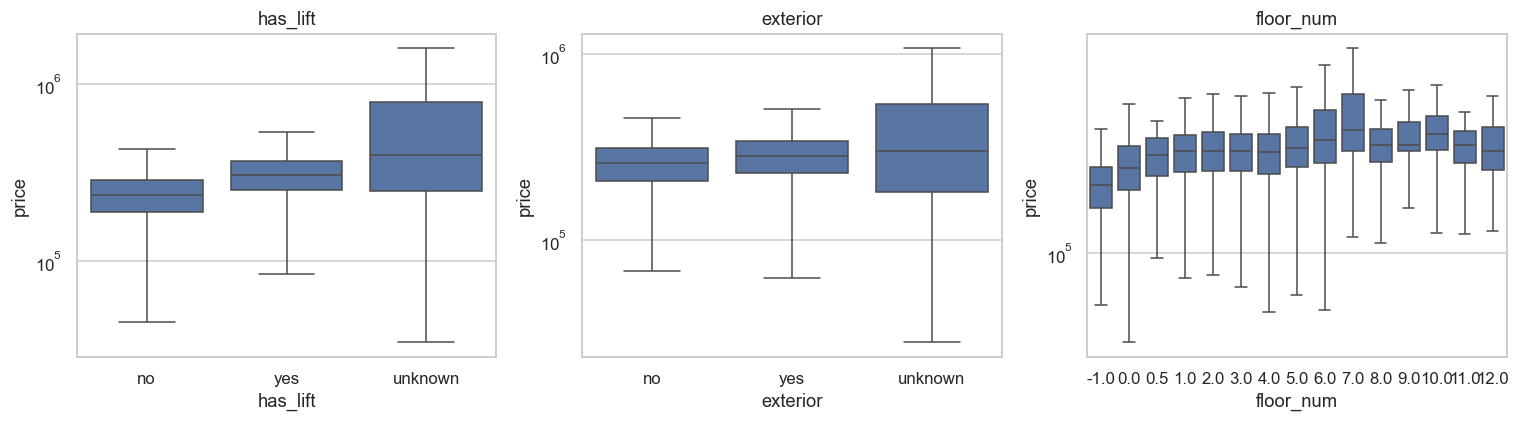

In [11]:
# Nullable booleans → labelled strings so NA is its own category (seaborn-safe).
d = clean.copy()
for c in ["has_lift", "exterior"]:
    d[c] = d[c].astype("object").where(d[c].notna(), "unknown").map(
        {True: "yes", False: "no", "unknown": "unknown"}
    )

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(data=d, x="has_lift", y="price", order=["no","yes","unknown"],
            showfliers=False, ax=ax[0])
ax[0].set(yscale="log", title="has_lift")
sns.boxplot(data=d, x="exterior", y="price", order=["no","yes","unknown"],
            showfliers=False, ax=ax[1])
ax[1].set(yscale="log", title="exterior")
sub = d[d["floor_num"].between(-1, 12)]
sns.boxplot(data=sub, x="floor_num", y="price", showfliers=False, ax=ax[2])
ax[2].set(yscale="log", title="floor_num")
plt.tight_layout()

## 10. Numeric correlations

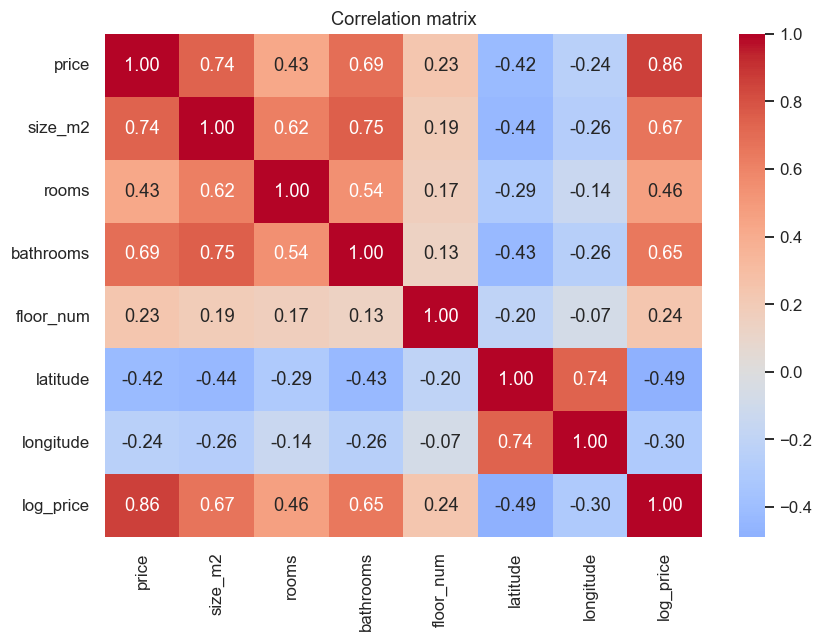

In [12]:
num = ["price", "size_m2", "rooms", "bathrooms", "floor_num", "latitude", "longitude"]
corr = clean[num].assign(log_price=np.log1p(clean["price"])).corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix"); plt.tight_layout()

## 11. Geography — price by location

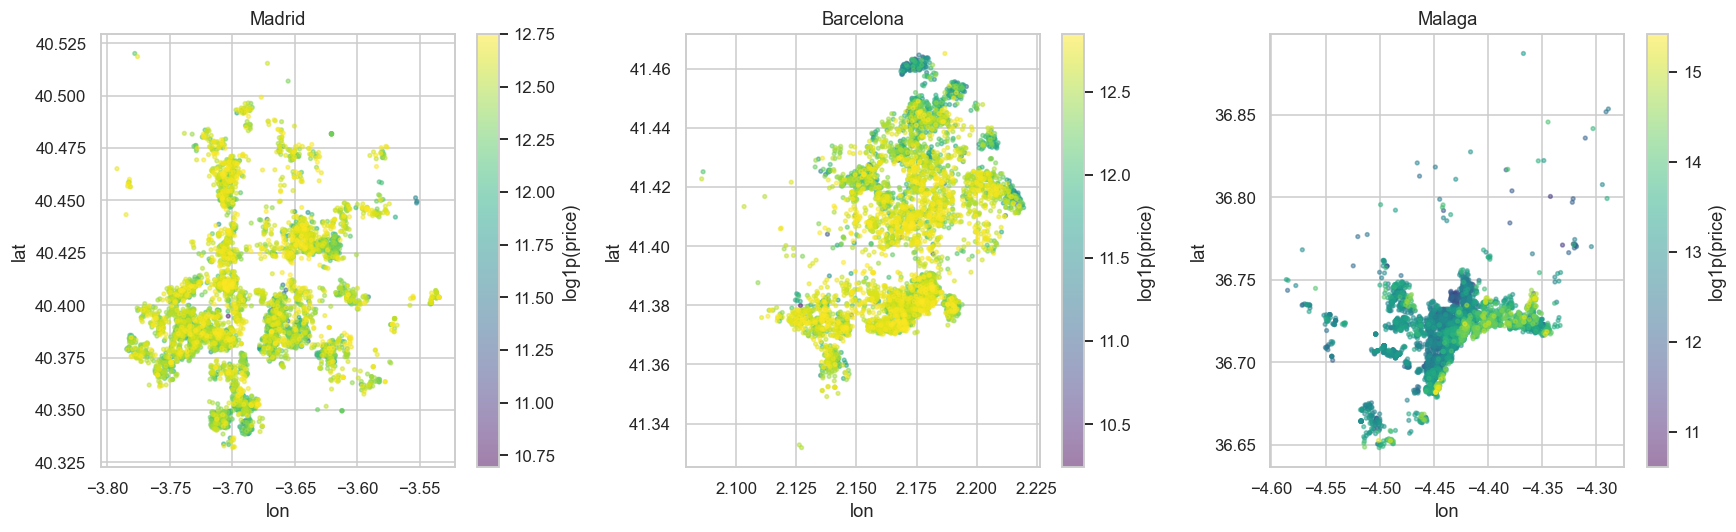

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, city in zip(axes, ["madrid", "barcelona", "malaga"]):
    g = clean[clean["city"] == city]
    sc = ax.scatter(g["longitude"], g["latitude"],
                    c=np.log1p(g["price"]), cmap="viridis", s=6, alpha=0.5)
    ax.set_title(city.title()); ax.set_xlabel("lon"); ax.set_ylabel("lat")
    plt.colorbar(sc, ax=ax, label="log1p(price)")
plt.tight_layout()

## 12. Sanity-check summary

Fill in after running:

- **Coverage** — core fields (price, size, rooms, baths, type, district,
  lat/lon) ~100%; `floor`/`exterior` partial (~85%).
- **Price/size** — right-skewed → `log1p(price)` target confirmed; `log size`
  is the strongest single correlate of `log price`.
- **€/m² by district** — ordering matches local knowledge (central/coastal
  districts highest). This is the sell-side anchor.
- **Outliers** — `clean_sale_listings` removed the obvious junk (32,000 m²
  listing, €5/m², €8.5M). Spot-check anything still surprising above.
- **Next** — feature engineering + model training in `sell_price_model.ipynb`.